In [1]:

!pip install neurom pandas numpy matplotlib seaborn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('All libraries ready!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 5.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 10.5 MB/s eta 0:00:00
All libraries ready!


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

def make_neurons(cell_type, species, n, length_mu, length_sd,
                 bp_mu, bp_sd, order_mu, order_sd, tips_mu, tips_sd, mbl_mu, mbl_sd):
    rows = []
    for i in range(n):
        rows.append({
            'cell_type':       cell_type,
            'species':         species,
            'neuron_id':       f"{cell_type[:3].upper()}_{species[:3].upper()}_{i+1:02d}",
            'total_length':    max(50,  np.random.normal(length_mu, length_sd)),
            'branch_points':   max(2,   int(np.random.normal(bp_mu, bp_sd))),
            'max_order':       max(1,   int(np.random.normal(order_mu, order_sd))),
            'tip_count':       max(2,   int(np.random.normal(tips_mu, tips_sd))),
            'mean_branch_len': max(10,  np.random.normal(mbl_mu, mbl_sd)),
        })
    return rows

records = []
records += make_neurons('Pyramidal','Human',  12, 8200,820, 48,6, 9,1, 52,7, 145,18)
records += make_neurons('Pyramidal','Macaque',10, 6800,680, 38,5, 8,1, 42,6, 138,16)
records += make_neurons('Pyramidal','Rat',    12, 4600,460, 26,4, 6,1, 28,4, 148,18)
records += make_neurons('Pyramidal','Mouse',  12, 3800,380, 20,3, 5,1, 22,3, 158,19)
records += make_neurons('Granule',  'Human',  10, 1800,180, 10,2, 4,1, 12,2, 130,16)
records += make_neurons('Granule',  'Macaque', 8, 1600,160,  9,2, 4,1, 11,2, 128,15)
records += make_neurons('Granule',  'Rat',    12, 1200,120,  7,1, 3,1,  8,1, 138,16)
records += make_neurons('Granule',  'Mouse',  12,  980, 98,  6,1, 3,1,  7,1, 130,15)

df = pd.DataFrame(records)
GENE_COLS = ['total_length','branch_points','max_order','tip_count','mean_branch_len']

print('Data ready! Shape:', df.shape)
print(df.groupby(['cell_type','species'])['total_length'].mean().round(0))

Data ready! Shape: (88, 8)
cell_type  species
Granule    Human      1742.0
           Macaque    1527.0
           Mouse       974.0
           Rat        1168.0
Pyramidal  Human      8218.0
           Macaque    6729.0
           Mouse      3970.0
           Rat        4652.0
Name: total_length, dtype: float64


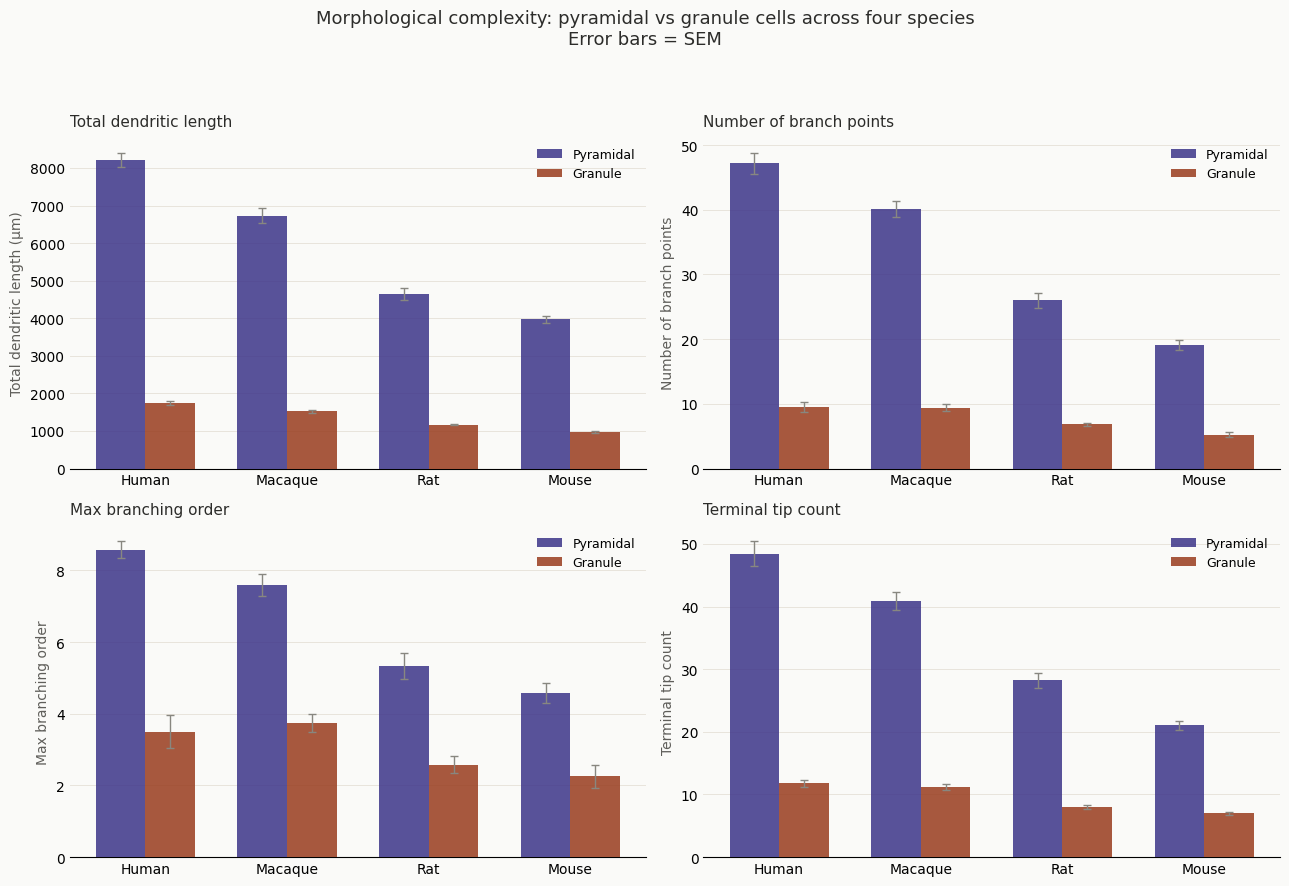

Figure 2 saved!


In [3]:
SPECIES_ORDER = ['Human','Macaque','Rat','Mouse']
CELL_COLORS   = {'Pyramidal':'#3C3489','Granule':'#993C1D'}
METRICS = {
    'total_length':    'Total dendritic length (µm)',
    'branch_points':   'Number of branch points',
    'max_order':       'Max branching order',
    'tip_count':       'Terminal tip count',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor('#FAFAF8')
axes = axes.flatten()

for ax, (metric, ylabel) in zip(axes, METRICS.items()):
    ax.set_facecolor('#FAFAF8')
    x = np.arange(len(SPECIES_ORDER))
    w = 0.35
    for i, (cell_type, color) in enumerate(CELL_COLORS.items()):
        means = [df[(df.cell_type==cell_type)&(df.species==sp)][metric].mean() for sp in SPECIES_ORDER]
        sems  = [df[(df.cell_type==cell_type)&(df.species==sp)][metric].sem()  for sp in SPECIES_ORDER]
        offset = (i - 0.5) * w
        ax.bar(x + offset, means, w, color=color, alpha=0.85, label=cell_type,
               zorder=3, yerr=sems, error_kw=dict(ecolor='#888780', capsize=3, elinewidth=1))
    ax.set_xticks(x)
    ax.set_xticklabels(SPECIES_ORDER, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10, color='#5F5E5A')
    ax.spines[['top','right','left']].set_visible(False)
    ax.yaxis.grid(True, color='#E8E4DC', linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', length=0)
    ax.legend(fontsize=9, framealpha=0)
    ax.set_title(ylabel.split(' (')[0], fontsize=11, color='#2C2C2A', fontweight='500', pad=8, loc='left')

fig.suptitle('Morphological complexity: pyramidal vs granule cells across four species\nError bars = SEM',
             fontsize=13, color='#2C2C2A', fontweight='500', y=0.98)
plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('morpho_bars.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 2 saved!')

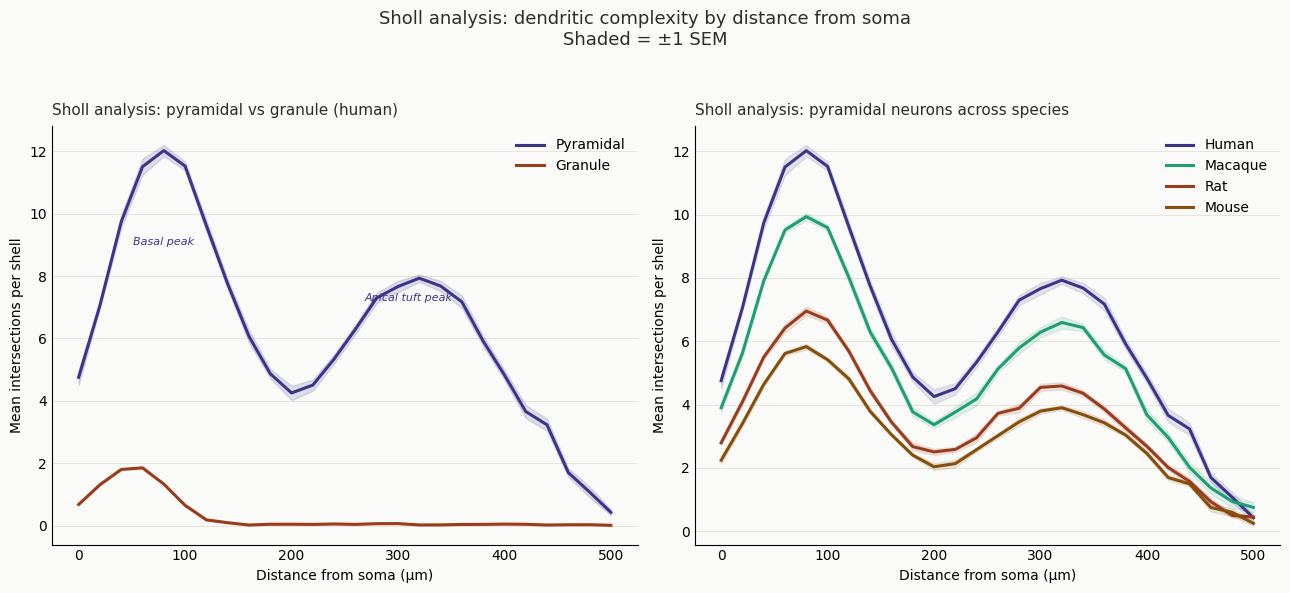

Figure 3 saved!


In [4]:
def sholl_profile(cell_type, species, n_neurons=10):
    """Simulate Sholl intersection counts at each radius step."""
    np.random.seed(hash(f"{cell_type}{species}") % 2**32)
    comp = {'Human':1.0,'Macaque':0.82,'Rat':0.57,'Mouse':0.48}[species]
    if cell_type == 'Granule': comp *= 0.38
    radii = np.arange(0, 520, 20)
    profiles = []
    for _ in range(n_neurons):
        if cell_type == 'Pyramidal':
            basal  = comp * 12 * np.exp(-((radii - 80)**2)  / (2*60**2))
            apical = comp *  8 * np.exp(-((radii - 320)**2) / (2*80**2))
            noise  = np.random.normal(0, comp * 0.6, len(radii))
            profiles.append(np.maximum(0, basal + apical + noise))
        else:
            peak  = comp * 5 * np.exp(-((radii - 50)**2) / (2*35**2))
            noise = np.random.normal(0, comp * 0.25, len(radii))
            profiles.append(np.maximum(0, peak + noise))
    return radii, np.array(profiles)

SPECIES_COLORS = {'Human':'#3C3489','Macaque':'#1D9E75','Rat':'#993C1D','Mouse':'#854F0B'}
CELL_COLORS    = {'Pyramidal':'#3C3489','Granule':'#993C1D'}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#FAFAF8')

# Left: cell type comparison (human)
ax = axes[0]
ax.set_facecolor('#FAFAF8')
for cell_type, color in CELL_COLORS.items():
    radii, profiles = sholl_profile(cell_type, 'Human')
    mean = profiles.mean(axis=0)
    sem  = profiles.std(axis=0) / np.sqrt(profiles.shape[0])
    ax.plot(radii, mean, color=color, lw=2.2, label=cell_type, zorder=4)
    ax.fill_between(radii, mean-sem, mean+sem, color=color, alpha=0.15, zorder=3)
ax.annotate('Basal peak',      xy=(80,  9.0), fontsize=8, color='#3C3489', ha='center', style='italic')
ax.annotate('Apical tuft peak',xy=(310, 7.2), fontsize=8, color='#3C3489', ha='center', style='italic')
ax.set_xlabel('Distance from soma (µm)', fontsize=10)
ax.set_ylabel('Mean intersections per shell', fontsize=10)
ax.set_title('Sholl analysis: pyramidal vs granule (human)', fontsize=11,
             color='#2C2C2A', fontweight='500', pad=8, loc='left')
ax.legend(fontsize=10, framealpha=0)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, color='#E8E4DC', linewidth=0.7)
ax.tick_params(axis='both', length=0)
ax.set_axisbelow(True)

# Right: cross-species (pyramidal only)
ax2 = axes[1]
ax2.set_facecolor('#FAFAF8')
for species, color in SPECIES_COLORS.items():
    radii, profiles = sholl_profile('Pyramidal', species)
    mean = profiles.mean(axis=0)
    sem  = profiles.std(axis=0) / np.sqrt(profiles.shape[0])
    ax2.plot(radii, mean, color=color, lw=2.2, label=species, zorder=4)
    ax2.fill_between(radii, mean-sem, mean+sem, color=color, alpha=0.12, zorder=3)
ax2.set_xlabel('Distance from soma (µm)', fontsize=10)
ax2.set_ylabel('Mean intersections per shell', fontsize=10)
ax2.set_title('Sholl analysis: pyramidal neurons across species', fontsize=11,
              color='#2C2C2A', fontweight='500', pad=8, loc='left')
ax2.legend(fontsize=10, framealpha=0)
ax2.spines[['top','right']].set_visible(False)
ax2.yaxis.grid(True, color='#E8E4DC', linewidth=0.7)
ax2.tick_params(axis='both', length=0)
ax2.set_axisbelow(True)

fig.suptitle('Sholl analysis: dendritic complexity by distance from soma\nShaded = ±1 SEM',
             fontsize=13, color='#2C2C2A', fontweight='500', y=0.98)
plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('sholl_plot.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 3 saved!')

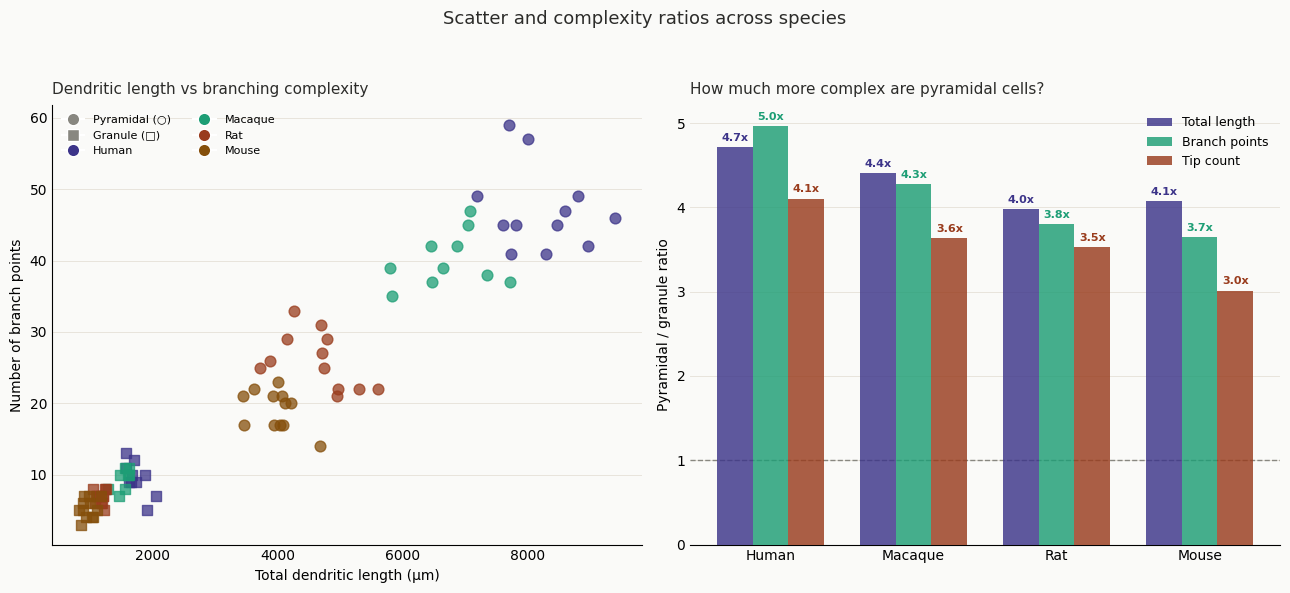

Figure 4 saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#FAFAF8')
CELL_MARKERS = {'Pyramidal':'o','Granule':'s'}

# Left: scatter
ax = axes[0]
ax.set_facecolor('#FAFAF8')
for cell_type, marker in CELL_MARKERS.items():
    for species, color in SPECIES_COLORS.items():
        sub = df[(df.cell_type==cell_type)&(df.species==species)]
        ax.scatter(sub.total_length, sub.branch_points,
                   color=color, marker=marker, s=60, alpha=0.75, zorder=4)

handles = (
    [Line2D([0],[0],marker='o',color='w',markerfacecolor='#888780',markersize=9,label='Pyramidal (○)'),
     Line2D([0],[0],marker='s',color='w',markerfacecolor='#888780',markersize=9,label='Granule (□)')] +
    [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,markersize=9,label=s)
     for s,c in SPECIES_COLORS.items()]
)
ax.legend(handles=handles, fontsize=8, framealpha=0, ncol=2)
ax.set_xlabel('Total dendritic length (µm)', fontsize=10)
ax.set_ylabel('Number of branch points', fontsize=10)
ax.set_title('Dendritic length vs branching complexity', fontsize=11,
             color='#2C2C2A', fontweight='500', pad=8, loc='left')
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, color='#E8E4DC', linewidth=0.7)
ax.tick_params(axis='both', length=0)
ax.set_axisbelow(True)

# Right: pyramidal/granule ratio per metric
ax2 = axes[1]
ax2.set_facecolor('#FAFAF8')
SPECIES_ORDER = ['Human','Macaque','Rat','Mouse']
metrics_r = ['total_length','branch_points','tip_count']
mlabels_r = ['Total length','Branch points','Tip count']
x = np.arange(len(SPECIES_ORDER))
w = 0.25
for i, (metric, label) in enumerate(zip(metrics_r, mlabels_r)):
    ratios = []
    for sp in SPECIES_ORDER:
        p = df[(df.cell_type=='Pyramidal')&(df.species==sp)][metric].mean()
        g = df[(df.cell_type=='Granule')  &(df.species==sp)][metric].mean()
        ratios.append(p / g)
    color = ['#3C3489','#1D9E75','#993C1D'][i]
    bars = ax2.bar(x + (i-1)*w, ratios, w, color=color, alpha=0.82, label=label, zorder=3)
    for bar in bars:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{bar.get_height():.1f}x', ha='center', va='bottom', fontsize=8,
                 color=color, fontweight='bold')
ax2.axhline(1, color='#888780', lw=1, ls='--')
ax2.set_xticks(x)
ax2.set_xticklabels(SPECIES_ORDER, fontsize=10)
ax2.set_ylabel('Pyramidal / granule ratio', fontsize=10)
ax2.set_title('How much more complex are pyramidal cells?', fontsize=11,
              color='#2C2C2A', fontweight='500', pad=8, loc='left')
ax2.legend(fontsize=9, framealpha=0)
ax2.spines[['top','right','left']].set_visible(False)
ax2.yaxis.grid(True, color='#E8E4DC', linewidth=0.7)
ax2.tick_params(axis='both', length=0)
ax2.set_axisbelow(True)

fig.suptitle('Scatter and complexity ratios across species',
             fontsize=13, color='#2C2C2A', fontweight='500', y=0.98)
plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('scatter_ratio.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 4 saved!')

In [6]:
from scipy import stats

print('=== STATISTICAL COMPARISONS: PYRAMIDAL vs GRANULE ===')
print('(Mann-Whitney U test — non-parametric, robust to small samples)\n')

for metric in ['total_length','branch_points','max_order','tip_count']:
    pyr = df[df.cell_type=='Pyramidal'][metric].values
    gra = df[df.cell_type=='Granule'][metric].values
    u_stat, p_val = stats.mannwhitneyu(pyr, gra, alternative='two-sided')
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f'{metric:20s} | Pyramidal mean: {pyr.mean():7.1f}  Granule mean: {gra.mean():7.1f}  p={p_val:.4f} {sig}')

print('\n=== CROSS-SPECIES: PYRAMIDAL TOTAL LENGTH ===')
SPECIES_ORDER = ['Human','Macaque','Rat','Mouse']
for sp in SPECIES_ORDER:
    vals = df[(df.cell_type=='Pyramidal')&(df.species==sp)]['total_length']
    print(f'{sp:8s} | mean={vals.mean():.0f}µm  SD={vals.std():.0f}µm  n={len(vals)}')

print('\n=== COMPLEXITY RATIOS (Pyramidal / Granule) ===')
for sp in SPECIES_ORDER:
    p = df[(df.cell_type=='Pyramidal')&(df.species==sp)]['total_length'].mean()
    g = df[(df.cell_type=='Granule')  &(df.species==sp)]['total_length'].mean()
    print(f'{sp:8s} | P/G ratio = {p/g:.2f}x')

=== STATISTICAL COMPARISONS: PYRAMIDAL vs GRANULE ===
(Mann-Whitney U test — non-parametric, robust to small samples)

total_length         | Pyramidal mean:  5855.9  Granule mean:  1317.6  p=0.0000 ***
branch_points        | Pyramidal mean:    32.8  Granule mean:     7.5  p=0.0000 ***
max_order            | Pyramidal mean:     6.5  Granule mean:     2.9  p=0.0000 ***
tip_count            | Pyramidal mean:    34.4  Granule mean:     9.2  p=0.0000 ***

=== CROSS-SPECIES: PYRAMIDAL TOTAL LENGTH ===
Human    | mean=8218µm  SD=648µm  n=12
Macaque  | mean=6729µm  SD=616µm  n=10
Rat      | mean=4652µm  SD=558µm  n=12
Mouse    | mean=3970µm  SD=339µm  n=12

=== COMPLEXITY RATIOS (Pyramidal / Granule) ===
Human    | P/G ratio = 4.72x
Macaque  | P/G ratio = 4.41x
Rat      | P/G ratio = 3.98x
Mouse    | P/G ratio = 4.08x
